2.序列模型：马尔可夫模型与拉普拉斯平滑
(1)统计序列中的转移频次
在序列 "ababc" 中，统计各个字符之间的转移情况（即上一个字符是啥，当前字符是啥）：
a -> b
b -> a
a -> b
b -> c
需要计算的是以 'b' 作为前置条件的概率，因此单独统计以 'b' 开头的转移次数：
Count(b→a)=1（出现了 1 次 ba）
Count(b→b)=0（没有出现 bb）
Count(b→c)=1（出现了 1 次 bc）
以 'b' 为前置条件的总转移次数 Count(b→∗)=1+0+1=2
(2)应用拉普拉斯平滑公式
加1平滑的公式为：
p(xt|xt−1)= Count(xt−1→xt)+1 / Count(xt−1→∗)+∣V∣
分子加1防止零概率，分母加上词汇表大小以保证概率总和仍为1。
(3)计算结果
p(′a′∣′b′) = Count(b→a)+1 / Count(b→∗)+∣V∣= 1+1 / 2+3 = 0.4

p(′c′∣′b′) = Count(b→c)+1 / Count(b→∗)+∣V∣= 1+1 / 2+3 = 0.4

In [1]:
import re
from collections import Counter

def preprocess_text(text, n):
    """
    自回归语言模型文本预处理函数
    :param text: 输入的原始字符串
    :param n: 滑动窗口的长度 (n-gram)
    :return: 词汇表字典, (特征列表, 标签列表)
    """
    
    # 1. 将文本转换为小写，去除标点符号（保留字母和空格）
    text_lower = text.lower()
    # 使用正则表达式替换：[^a-z\s] 意味着“除了小写字母和空白字符以外的所有字符”全部替换为空
    clean_text = re.sub(r'[^a-z\s]', '', text_lower)
    
    # 2. 按空格分词
    tokens = clean_text.split()
    
    # 3. 构建词汇表（按出现频率排序，分配整数ID，从0开始）
    # Counter.most_common() 会自动按词频从高到低返回元素及其频次
    word_counts = Counter(tokens)
    vocab_dict = {}
    for idx, (word, count) in enumerate(word_counts.most_common()):
        vocab_dict[word] = idx
        
    # 4. 用滑动窗口生成长度为 n 的特征序列和对应的下一个词标签
    features = []
    labels = []
    
    # 滑动窗口的起始点必须保证能截取到 n 个词
    for i in range(len(tokens) - n + 1):
        # 提取长度为 n 的特征序列
        feature = tokens[i : i+n]
        features.append(feature)
        
        # 判断是否有下一个词作为标签
        if i + n < len(tokens):
            labels.append(tokens[i+n])
        else:
            labels.append(None) # 如果没有后续词，按要求填入 None
            
    return vocab_dict, (features, labels)

# ==========================================
# 测试与验证代码
# ==========================================
if __name__ == "__main__":
    # 使用题目中给定的例子进行测试
    test_text = "The time machine"
    window_size = 2
    
    vocab, (features, labels) = preprocess_text(test_text, window_size)
    
    print(f"输入文本: '{test_text}'")
    print(f"窗口大小 n: {window_size}\n")
    
    print(f"1. 生成的词汇表 (按频率排序, ID从0开始):")
    print(f"   {vocab}\n")
    
    print(f"2. 生成的特征列表:")
    print(f"   {features}\n")
    
    print(f"3. 生成的标签列表:")
    print(f"   {labels}")

输入文本: 'The time machine'
窗口大小 n: 2

1. 生成的词汇表 (按频率排序, ID从0开始):
   {'the': 0, 'time': 1, 'machine': 2}

2. 生成的特征列表:
   [['the', 'time'], ['time', 'machine']]

3. 生成的标签列表:
   ['machine', None]


3.循环神经网络：线性 RNN 的 BPTT 梯度推导与消失/爆炸条件
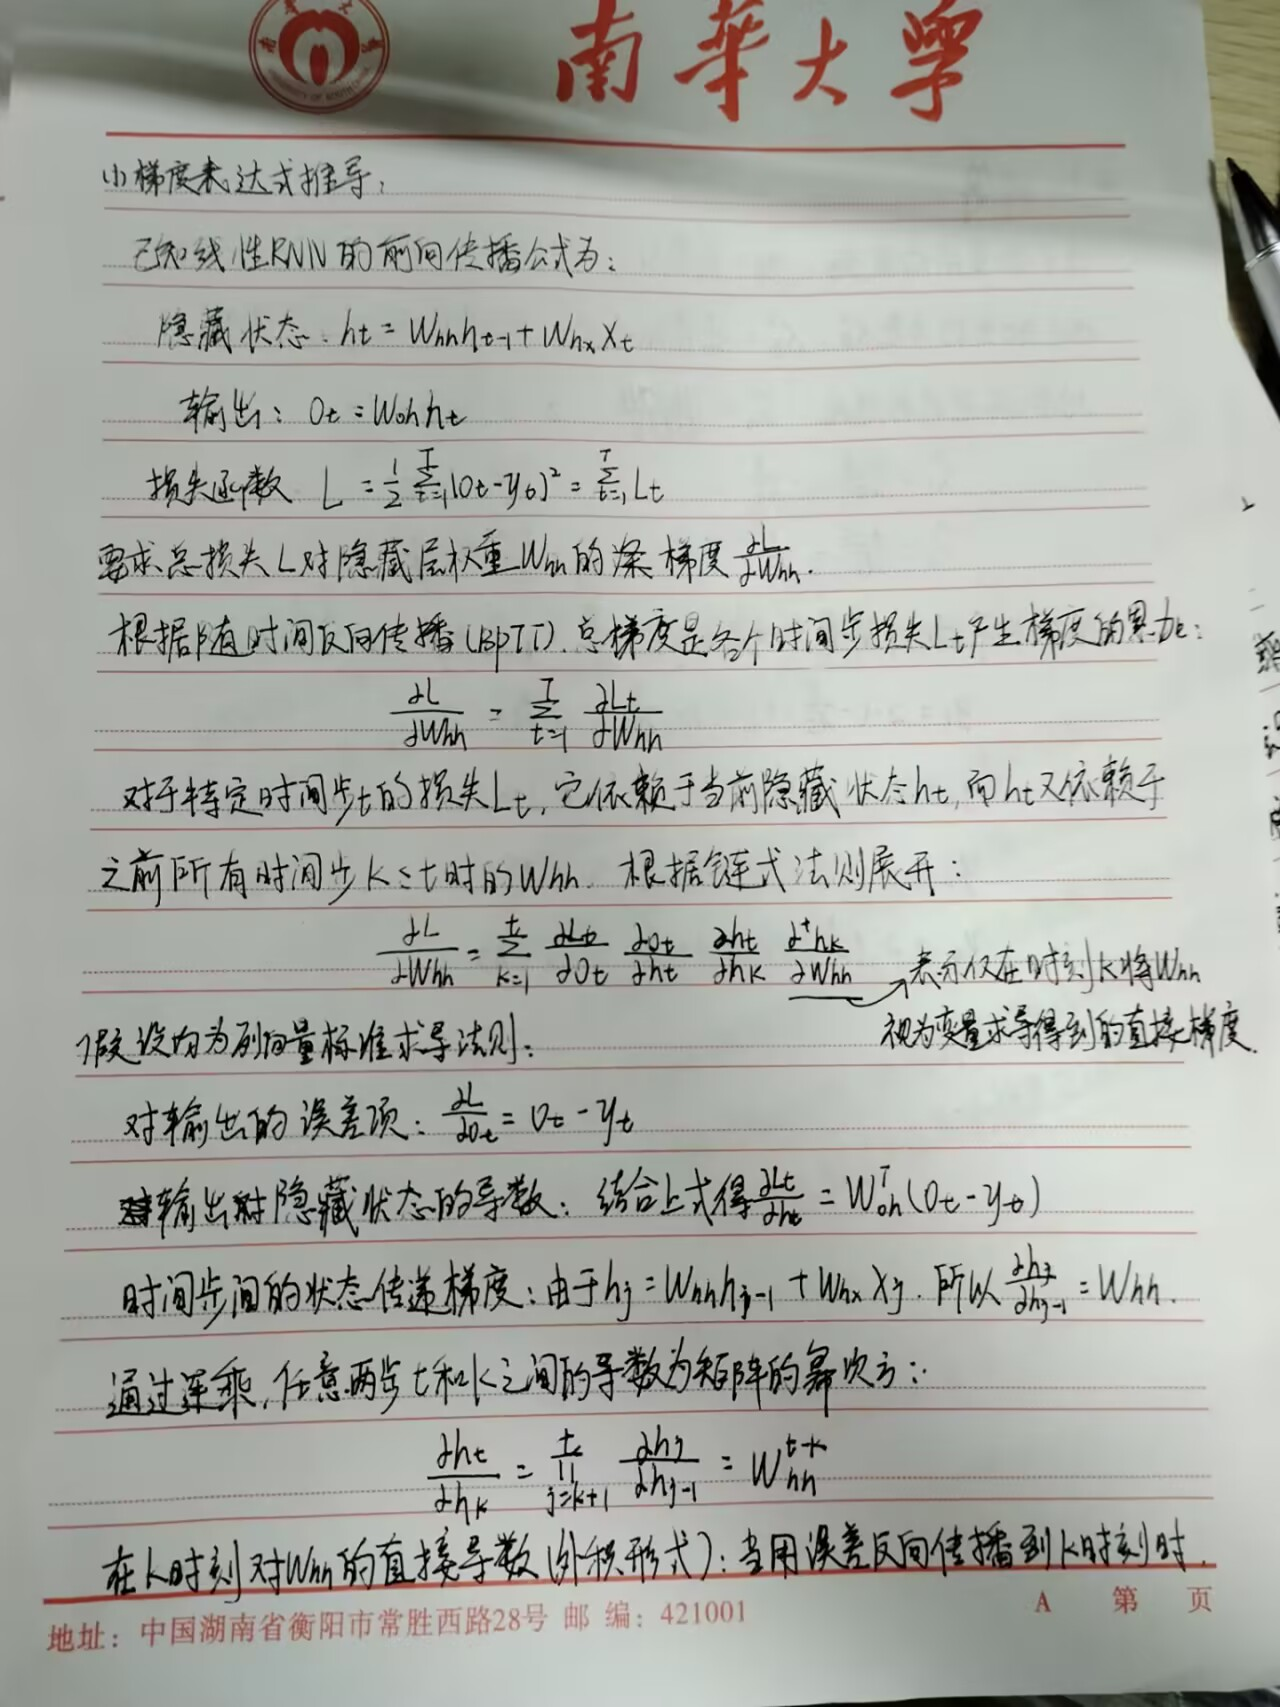
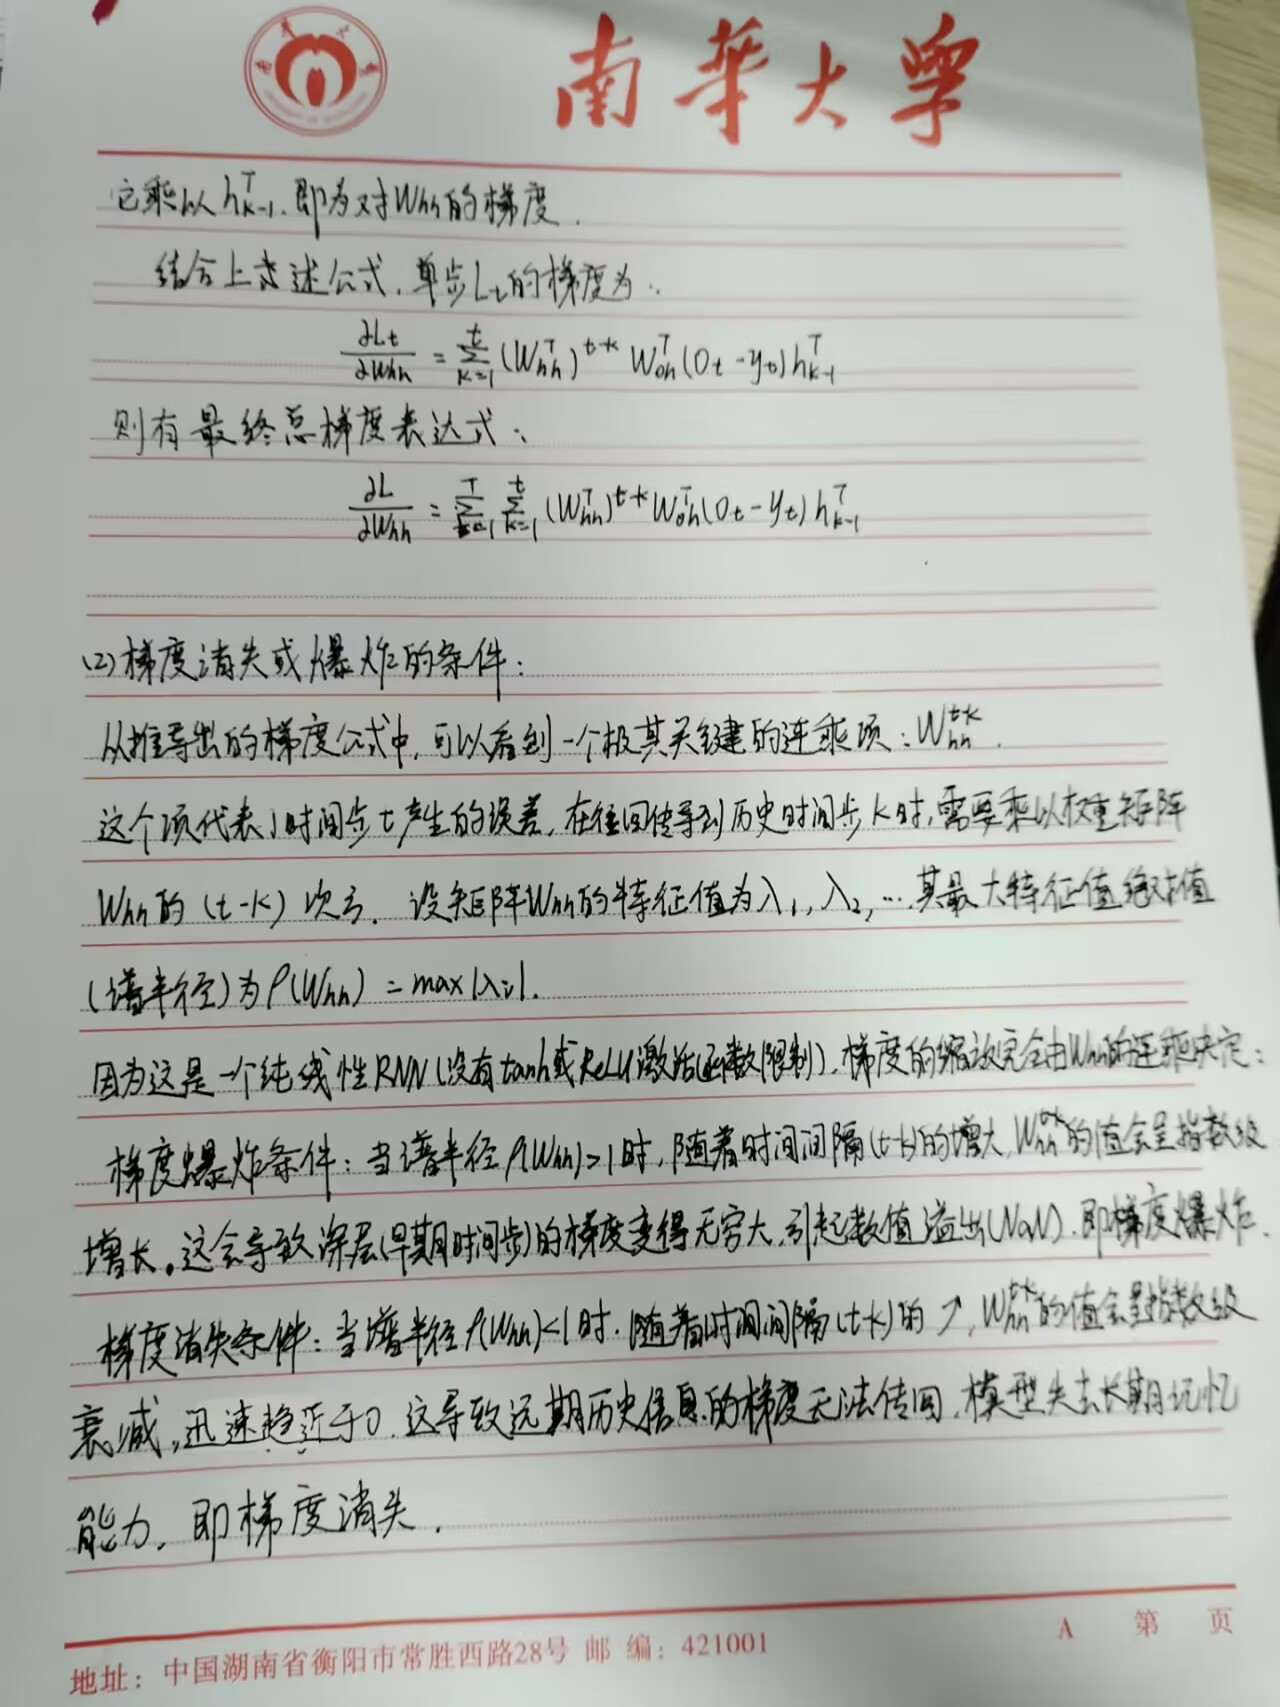

In [2]:
import numpy as np

def rnn_step_forward(x_t, h_prev, W_hx, W_hh, b_h):
    """
    RNN 单步前向传播
    
    参数:
    x_t: 当前输入，形状 (batch_size, input_size)
    h_prev: 上一步隐藏状态，形状 (batch_size, hidden_size)
    W_hx: 输入到隐藏层的权重，形状 (input_size, hidden_size)
    W_hh: 隐藏层到隐藏层的权重，形状 (hidden_size, hidden_size)
    b_h: 隐藏层偏置，形状 (hidden_size,)
    
    返回:
    h_t: 当前隐藏状态
    cache: 供反向传播使用的缓存元组
    """
    # 计算仿射变换结果 z_t
    z_t = np.dot(x_t, W_hx) + np.dot(h_prev, W_hh) + b_h
    
    # 经过 tanh 激活函数
    h_t = np.tanh(z_t)
    
    # 保存反向传播需要的变量
    cache = (x_t, h_prev, h_t, W_hx, W_hh)
    
    return h_t, cache


def rnn_step_backward(dh_next, cache):
    """
    RNN 单步反向传播
    
    参数:
    dh_next: 上游传来的梯度（损失关于 h_t 的梯度），形状 (batch_size, hidden_size)
    cache: 前向传播保存的缓存
    
    返回:
    dx_t, dh_prev, dW_hx, dW_hh, db_h
    """
    x_t, h_prev, h_t, W_hx, W_hh = cache
    
    # 1. 穿过 tanh 激活函数： d(tanh(x))/dx = 1 - tanh^2(x) = 1 - h_t^2
    # 注意这里是 element-wise 乘法
    dtanh = 1.0 - h_t ** 2
    dz_t = dh_next * dtanh  # 形状: (batch_size, hidden_size)
    
    # 2. 对矩阵乘法进行反向传播 (链式法则)
    # x_t 的梯度：dz_t 乘以 W_hx 的转置
    dx_t = np.dot(dz_t, W_hx.T)      # (batch, hidden) x (hidden, input) -> (batch, input)
    
    # h_prev 的梯度：dz_t 乘以 W_hh 的转置 (这就是要继续往历史时间步传的梯度)
    dh_prev = np.dot(dz_t, W_hh.T)   # (batch, hidden) x (hidden, hidden) -> (batch, hidden)
    
    # W_hx 的梯度：x_t 的转置 乘以 dz_t
    dW_hx = np.dot(x_t.T, dz_t)      # (input, batch) x (batch, hidden) -> (input, hidden)
    
    # W_hh 的梯度：h_prev 的转置 乘以 dz_t
    dW_hh = np.dot(h_prev.T, dz_t)   # (hidden, batch) x (batch, hidden) -> (hidden, hidden)
    
    # 偏置 b_h 的梯度：沿着 batch 维度求和
    db_h = np.sum(dz_t, axis=0)      # (hidden_size,)
    
    return dx_t, dh_prev, dW_hx, dW_hh, db_h

# ==========================================
# 测试与验证代码 (验证尺寸是否匹配)
# ==========================================
if __name__ == "__main__":
    np.random.seed(42)
    batch_size, input_size, hidden_size = 4, 10, 8
    
    x_t = np.random.randn(batch_size, input_size)
    h_prev = np.random.randn(batch_size, hidden_size)
    W_hx = np.random.randn(input_size, hidden_size)
    W_hh = np.random.randn(hidden_size, hidden_size)
    b_h = np.random.randn(hidden_size)
    
    # 前向传播测试
    h_t, cache = rnn_step_forward(x_t, h_prev, W_hx, W_hh, b_h)
    print("Forward h_t shape:", h_t.shape)  # 预期 (4, 8)
    
    # 模拟上游传来的梯度
    dh_next = np.random.randn(batch_size, hidden_size)
    
    # 反向传播测试
    dx_t, dh_prev, dW_hx, dW_hh, db_h = rnn_step_backward(dh_next, cache)
    
    print("Backward dx_t shape:", dx_t.shape)       # 预期 (4, 10)
    print("Backward dh_prev shape:", dh_prev.shape) # 预期 (4, 8)
    print("Backward dW_hx shape:", dW_hx.shape)     # 预期 (10, 8)
    print("Backward dW_hh shape:", dW_hh.shape)     # 预期 (8, 8)
    print("Backward db_h shape:", db_h.shape)       # 预期 (8,)

Forward h_t shape: (4, 8)
Backward dx_t shape: (4, 10)
Backward dh_prev shape: (4, 8)
Backward dW_hx shape: (10, 8)
Backward dW_hh shape: (8, 8)
Backward db_h shape: (8,)


4.高级循环神经网络：深度双向 RNN 参数量推导
已知变量定义：
网络层数：L
单向隐藏单元数：H
输入维度：D
输出维度：O
模型结构：深度双向 RNN（包含前向和后向两个独立的 RNN 链）
参数计算拆解（基于标准 RNN 数学定义，每层含 1 个偏置向量 b∈R^H）：
(1)第一层 (Layer 1)：
第一层直接接收维度为 D的输入序列。
前向 RNN：
输入权重 W(hx)：H×D
隐藏层权重 W(hh):H×H
偏置 b(h):H
前向参数量 = DH+H^2+H
后向 RNN： 结构与前向完全对称，参数量相同 = DH+H^2+H
第一层总参数量 = 2(DH+H^2+H)
(2)隐藏层 (Layer 2 到 Layer L)：
在深度双向 RNN 中，从第二层开始，每一层的输入是上一层前向和后向隐藏状态的拼接。因此，输入维度变成了2H。
共有 (L−1) 个这样的隐藏层。对于其中任意一层：
前向 RNN：
输入权重 W(hx):H×2H=2H^2
隐藏层权重 W(hh):H×H=H^2
偏置 b(h):H
前向参数量 = 2H^2+H^2+H=3H^2+H
后向 RNN：参数量相同 = 3H^2+H
单层隐藏层参数量 = 6H^2+2H
所有 (L−1) 个隐藏层总参数量 = (L−1)(6H^2+2H)
(3)最终输出层 (Output Layer)：
最后一层的输出是将第 L 层的前向和后向隐藏状态拼接，维度为2H，然后通过全连接层映射到输出维度O。
输出权重 W(oh):O×2H=2HO
输出偏置 b(o):O
输出层总参数量 = 2HO+O
最终表达式：
将上述三部分相加，得到该模型的参数总数表达式：
Total_Params=2(DH+H^2+H)+(L−1)(6H^2+2H)+2HO+O
(化简形式：2DH−4H^2+6LH^2+2LH+2HO+O)

In [3]:
import torch
import torch.nn as nn

class BiRNNEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1):
        """
        双向 RNN 编码器
        :param input_dim: 输入特征维度
        :param hidden_dim: 单向隐藏状态维度
        :param num_layers: RNN的层数
        """
        super(BiRNNEncoder, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # 使用 PyTorch 官方 API 定义双向 RNN
        # batch_first=False 意味着输入形状必须为 (seq_len, batch, input_dim)
        self.rnn = nn.RNN(input_size=input_dim, 
                          hidden_size=hidden_dim, 
                          num_layers=num_layers,
                          bidirectional=True, 
                          batch_first=False)

    def forward(self, x):
        """
        前向传播
        :param x: 形状为 (seq_len, batch, input_dim)
        :return: 
            out: 每个时间步的拼接隐藏状态 (seq_len, batch, 2*hidden_dim)
            final_repr: 最终的序列表示 (batch, 2*hidden_dim)
        """
        # out 形状: (seq_len, batch, 2 * hidden_dim)
        # h_n 形状: (num_layers * 2, batch, hidden_dim)
        out, h_n = self.rnn(x)
        
        # 提取最后一层的最终状态构建序列级表示
        # 在 PyTorch 中，h_n 的第一维中，偶数索引(0,2...)是前向状态，奇数索引(1,3...)是后向状态
        # 我们需要最后一层(num_layers-1)的前向和后向最终状态
        
        # 1. 最后一层的前向最终状态 (位于序列末尾)
        forward_final_hidden = h_n[-2, :, :]  # 形状: (batch, hidden_dim)
        
        # 2. 最后一层的后向最终状态 (位于序列开头)
        backward_final_hidden = h_n[-1, :, :] # 形状: (batch, hidden_dim)
        
        # 3. 将两者在特征维度(dim=1)拼接起来
        final_repr = torch.cat((forward_final_hidden, backward_final_hidden), dim=1) 
        # final_repr 形状: (batch, 2 * hidden_dim)
        
        return out, final_repr

# ==========================================
# 测试与验证代码
# ==========================================
if __name__ == "__main__":
    # 定义超参数
    seq_len = 5
    batch_size = 3
    input_dim = 10
    hidden_dim = 8
    
    # 随机生成模拟输入序列
    X = torch.randn(seq_len, batch_size, input_dim)
    
    # 实例化模型
    encoder = BiRNNEncoder(input_dim=input_dim, hidden_dim=hidden_dim)
    
    # 执行前向传播
    all_step_out, sequence_repr = encoder(X)
    
    # 打印形状以验证是否符合题目要求
    print(f"输入序列 X 形状: {X.shape} -> (seq_len, batch, input_dim)")
    print("-" * 50)
    print(f"要求1: 所有时间步的拼接状态 (out) 形状: {all_step_out.shape}")
    print(f"       预期形状: ({seq_len}, {batch_size}, {2 * hidden_dim})")
    print("-" * 50)
    print(f"要求2: 最终的序列表示 (final_repr) 形状: {sequence_repr.shape}")
    print(f"       预期形状: ({batch_size}, {2 * hidden_dim})")
    
    # 深入验证: 检查 out[-1] 与 sequence_repr 是否不同 (证明我们成功避开了陷阱)
    is_same = torch.allclose(all_step_out[-1], sequence_repr)
    print("-" * 50)
    print(f"验证陷阱: out 的最后一个时间步是否等于最终序列表示？ -> {'是 (错误)' if is_same else '否 (正确)'}")

输入序列 X 形状: torch.Size([5, 3, 10]) -> (seq_len, batch, input_dim)
--------------------------------------------------
要求1: 所有时间步的拼接状态 (out) 形状: torch.Size([5, 3, 16])
       预期形状: (5, 3, 16)
--------------------------------------------------
要求2: 最终的序列表示 (final_repr) 形状: torch.Size([3, 16])
       预期形状: (3, 16)
--------------------------------------------------
验证陷阱: out 的最后一个时间步是否等于最终序列表示？ -> 否 (正确)


5.嵌入向量:Skip-gram 与负采样 (Negative Sampling)
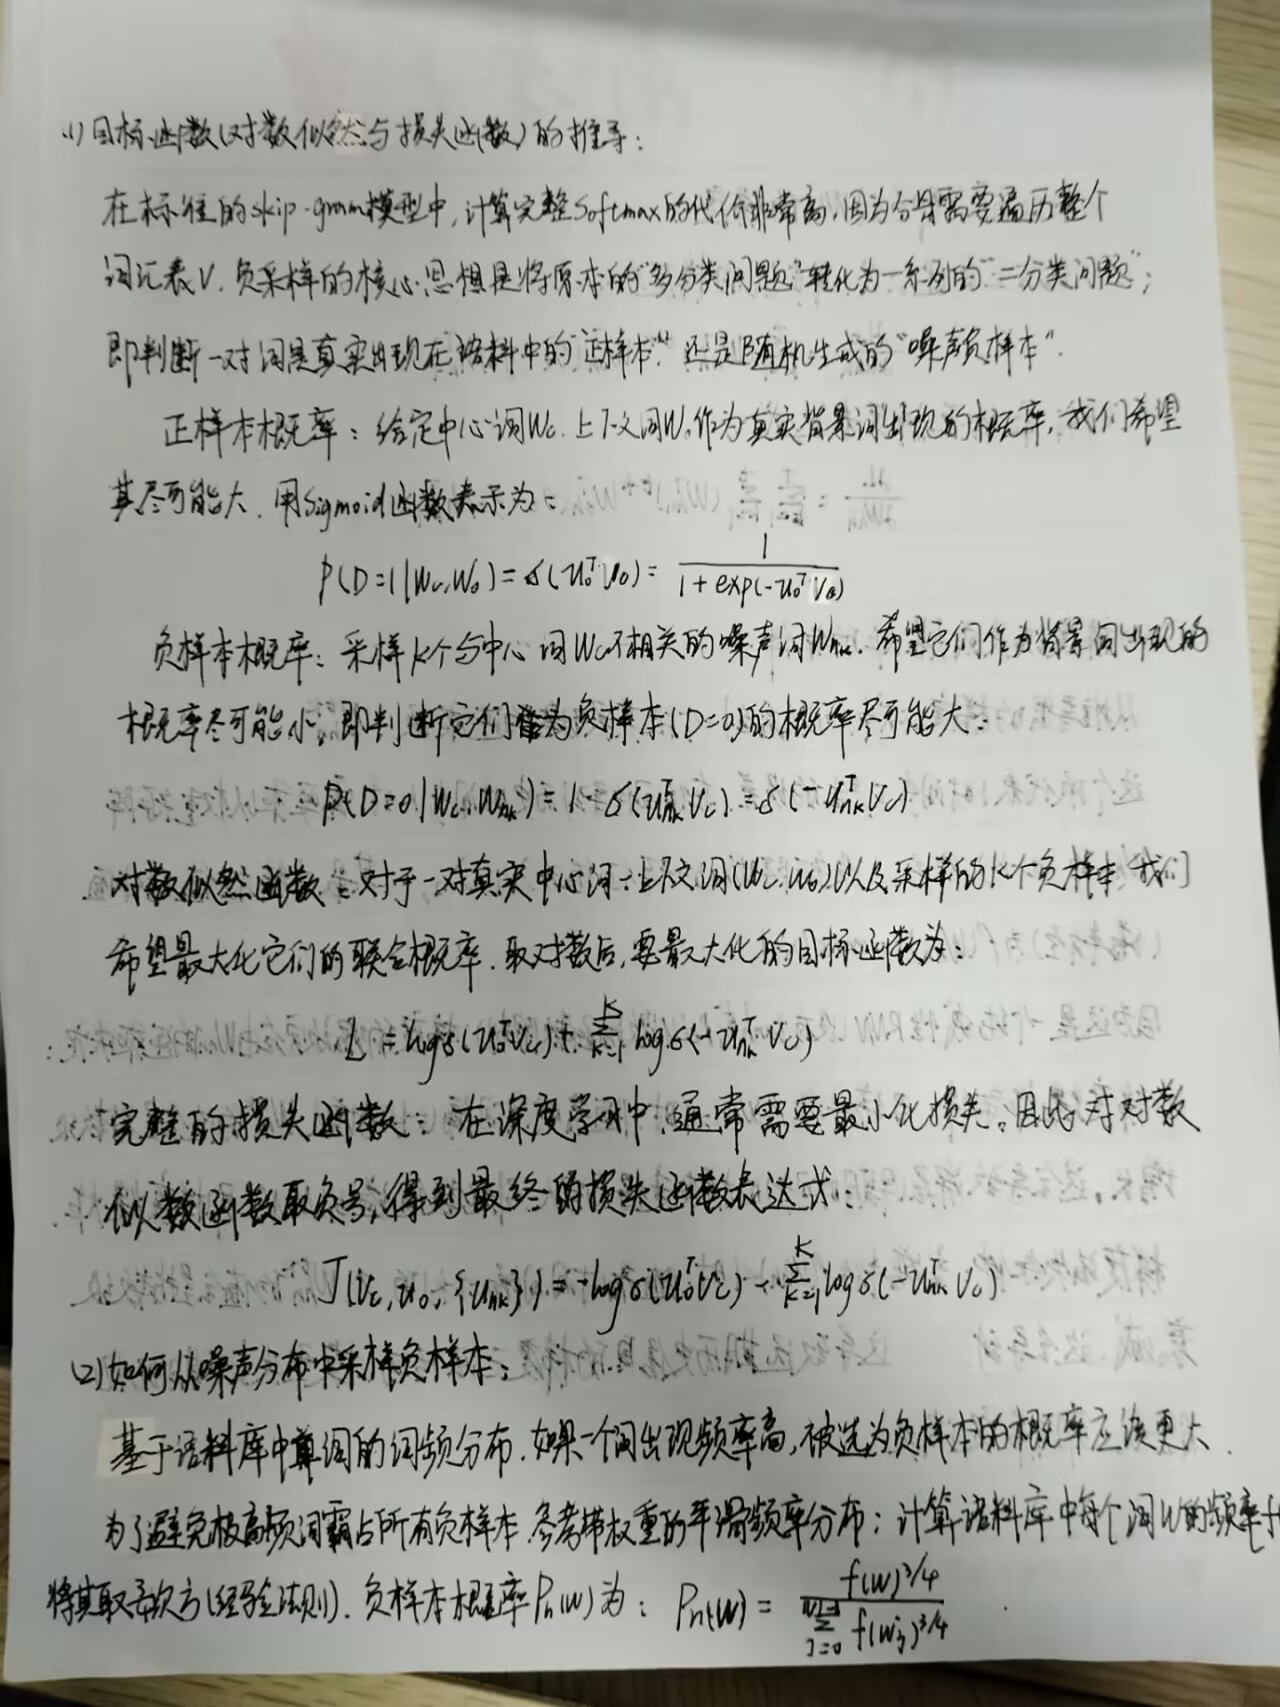

In [4]:
import torch
import torch.nn.functional as F

def cbow_forward_and_loss(context_indices, target_indices, W, W_out):
    """
    计算 CBOW 模型的前向传播和交叉熵损失 (完整 Softmax)
    
    参数:
    - context_indices: 上下文词的索引，形状为 (batch_size, context_size)
    - target_indices: 目标中心词的索引，形状为 (batch_size,)
    - W: 输入词向量矩阵，形状为 (V, d)
    - W_out: 输出词向量矩阵，形状为 (d, V)
    
    返回:
    - loss: 标量，批次的平均交叉熵损失
    """
    # 获取维度信息
    batch_size, context_size = context_indices.shape
    
    # 1. 查找上下文词的嵌入向量 (Look up embeddings)
    # 利用 PyTorch 的高级索引功能，直接用 context_indices 去切片 W 矩阵
    # context_embeds 形状变为: (batch_size, context_size, d)
    context_embeds = W[context_indices]
    
    # 2. 计算平均上下文向量作为隐藏层 (Average Context Vectors)
    # 沿着 context_size 维度 (dim=1) 求平均
    # hidden 形状变为: (batch_size, d)
    hidden = context_embeds.mean(dim=1)
    
    # 3. 计算输出概率分布的未归一化 logits
    # 执行矩阵乘法: (batch_size, d) @ (d, V) -> (batch_size, V)
    logits = torch.matmul(hidden, W_out)
    
    # 4. 计算交叉熵损失 (Cross Entropy Loss)
    # F.cross_entropy 内部自动集成了 softmax 和负对数似然计算
    # logits 形状 (batch_size, V), target_indices 形状 (batch_size,)
    loss = F.cross_entropy(logits, target_indices)
    
    return loss

# ==========================================
# 测试与验证代码
# ==========================================
if __name__ == "__main__":
    # 固定随机种子以便结果复现
    torch.manual_seed(42)
    
    # 定义超参数
    V = 10000        # 词汇表大小
    d = 128          # 嵌入维度
    batch_size = 4   # 批次大小
    context_size = 6 # 每个样本有 6 个上下文词 (例如中心词左右各 3 个)
    
    # 1. 初始化输入权重 W 和 输出权重 W_out
    W = torch.randn(V, d, requires_grad=True)
    W_out = torch.randn(d, V, requires_grad=True)
    
    # 2. 模拟一批数据
    # 生成范围在 [0, V) 的随机整数作为上下文索引和目标索引
    context_indices = torch.randint(0, V, (batch_size, context_size))
    target_indices = torch.randint(0, V, (batch_size,))
    
    # 3. 计算损失
    loss = cbow_forward_and_loss(context_indices, target_indices, W, W_out)
    
    print(f"--- CBOW 完整 Softmax 损失计算 ---")
    print(f"上下文索引矩阵形状: {context_indices.shape}")
    print(f"目标索引向量形状:   {target_indices.shape}")
    print(f"输入矩阵 W 形状:    {W.shape}")
    print(f"输出矩阵 W_out 形状: {W_out.shape}")
    print(f"----------------------------------")
    print(f"计算得到的 Loss 值: {loss.item():.4f}")
    
    # 验证梯度是否可以正常回传 (非常重要：证明计算图没有断裂)
    loss.backward()
    print(f"验证反向传播，W 的梯度形状: {W.grad.shape}")
    print(f"计算完毕！")

--- CBOW 完整 Softmax 损失计算 ---
上下文索引矩阵形状: torch.Size([4, 6])
目标索引向量形状:   torch.Size([4])
输入矩阵 W 形状:    torch.Size([10000, 128])
输出矩阵 W_out 形状: torch.Size([128, 10000])
----------------------------------
计算得到的 Loss 值: 20.6556
验证反向传播，W 的梯度形状: torch.Size([10000, 128])
计算完毕！


6.注意力机制:缩放点积注意力
已知参数：
查询矩阵 Q∈R^2×4（2个查询词，维度为4）
键矩阵 K∈R^3×4（3个背景词的键，维度为4）
值矩阵 V∈R^3×5（3个背景词的值，维度为5）
缩放因子 d(k)=4
(1)计算未缩放的得分矩阵 (Raw Scores)
将查询矩阵 Q 与键矩阵的转置 K^T 相乘。
K^T的形状为4×3。
Scores=Q⋅K^T 
形状变化：(2×4)×(4×3)→2×3。
物理意义： 得到了一个 2×3 的矩阵，代表 2 个查询词分别对 3 个背景词的相似度打分。
(2)缩放得分矩阵 (Scaled Scores)
将上一步的得分除以 √d(k)。已知d(k)= 4,所以 √d(k) = 2。
Scaled_Scores= Q⋅K^T / 2
形状保持不变，仍为 2×3。
物理意义： 防止点积结果过大导致 Softmax 进入饱和区（梯度消失）。
(3)计算注意力权重 (Attention Weights - Softmax)
对缩放后的得分矩阵沿着最后一个维度（即对那 3 个背景词的得分）进行 Softmax 归一化处理。
Attention=Softmax( Q⋅K^T / 2 )
形状保持不变，仍为 2×3。
物理意义： 矩阵每一行的 3 个数值相加等于 1，代表查询词分配给 3 个背景词的注意力权重概率。
(4)加权求和计算最终输出 (Weighted Sum with Values)
将注意力权重矩阵与值矩阵 V 相乘。
Output=Attention⋅V=Softmax( Q⋅K^T / 2 ) ⋅ V
形状变化：(2×3)×(3×5)→2×5。
最终答案为：
缩放点积注意力的最终输出矩阵形状为 2×5。
其完整计算公式为：Output=Softmax( Q⋅K^T / 2 ) ⋅ V 

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=4, num_heads=2):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        
        # 验证 d_model 是否可以被 num_heads 整除
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_k = d_model // num_heads  # 每个头的维度 d_k = d_v = 2
        
        # 定义生成 Q, K, V 的线性投影层
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # 定义拼接后的最终线性投影层
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, X):
        """
        前向传播
        参数 X 形状: (seq_len, batch, d_model)
        """
        seq_len, batch, _ = X.shape
        
        # 1. 线性投影得到总的 Q, K, V
        # 形状均变为: (seq_len, batch, d_model)
        Q = self.W_q(X)
        K = self.W_k(X)
        V = self.W_v(X)
        
        # 2. 拆分多头 (Split Heads)
        # 将 d_model 拆分成 (num_heads, d_k)
        # 变形后: (seq_len, batch, num_heads, d_k)
        Q = Q.view(seq_len, batch, self.num_heads, self.d_k)
        K = K.view(seq_len, batch, self.num_heads, self.d_k)
        V = V.view(seq_len, batch, self.num_heads, self.d_k)
        
        # 调整维度顺序以进行高效的批量矩阵乘法 (Batch Matrix Multiplication)
        # 将 batch 和 num_heads 移到前面: (batch, num_heads, seq_len, d_k)
        Q = Q.permute(1, 2, 0, 3)
        K = K.permute(1, 2, 0, 3)
        V = V.permute(1, 2, 0, 3)
        
        # 3. 计算缩放点积注意力 (Scaled Dot-Product Attention)
        # Q 与 K 的转置相乘。K 转置最后两维变为 (batch, num_heads, d_k, seq_len)
        # scores 形状: (batch, num_heads, seq_len, seq_len)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # 沿着最后一个维度计算 Softmax 得到注意力权重
        attn_weights = F.softmax(scores, dim=-1)
        
        # 权重乘以 V: (batch, num_heads, seq_len, seq_len) @ (batch, num_heads, seq_len, d_k)
        # context 形状: (batch, num_heads, seq_len, d_k)
        context = torch.matmul(attn_weights, V)
        
        # 4. 拼接所有头的输出 (Concatenate Heads)
        # 先把维度顺序调回到 (seq_len, batch, num_heads, d_k)
        context = context.permute(2, 0, 1, 3)
        
        # 合并 num_heads 和 d_k 维度 (恢复成 d_model)
        # contiguous() 是必需的，因为 permute 破坏了张量在内存中的连续性
        # concat_context 形状: (seq_len, batch, d_model)
        concat_context = context.contiguous().view(seq_len, batch, self.d_model)
        
        # 5. 经过最终的线性层
        # output 形状: (seq_len, batch, d_model)
        output = self.W_o(concat_context)
        
        return output

# ==========================================
# 测试与验证代码
# ==========================================
if __name__ == "__main__":
    # 按照题目要求设定超参数
    seq_len = 5
    batch_size = 3
    d_model = 4
    num_heads = 2
    
    # 初始化模型
    mha = MultiHeadAttention(d_model=d_model, num_heads=num_heads)
    
    # 模拟输入序列 X
    X = torch.randn(seq_len, batch_size, d_model)
    
    # 前向传播
    output = mha(X)
    
    print(f"输入 X 形状: {X.shape}")
    print(f"输出形状:    {output.shape}")
    print("-" * 40)
    print("验证通过：输出形状与输入完全一致，多头注意力前向计算成功！")

输入 X 形状: torch.Size([5, 3, 4])
输出形状:    torch.Size([5, 3, 4])
----------------------------------------
验证通过：输出形状与输入完全一致，多头注意力前向计算成功！
